# Gemma3-SD: Dual CLIP Scaffold → Native Gemma Conditioning for Stable Diffusion 1.5

Goal: migrate SD1.5 from CLIP conditioning to Gemma 3 270M native conditioning without relying on a CLIP-space linear bake.

Transition path:

```text
SD1.5 CLIP path intact
    + native Gemma cross-attention branch
    → train Gemma branch under CLIP scaffold
    → distill/anneal CLIP away
    → prune to Gemma-only inference
```

CLIP is a training scaffold and teacher. Final target is no CLIP at inference.


## Section 0: Google Drive Mount

Mount Google Drive for saving all artifacts (probe, LoRA, samples, complete model).

In [1]:
# @title 0.1 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_OUT = '/content/drive/MyDrive/gemma3-sd'
os.makedirs(DRIVE_OUT, exist_ok=True)
print(f"Artifacts will be saved to: {DRIVE_OUT}")


Mounted at /content/drive
Artifacts will be saved to: /content/drive/MyDrive/gemma3-sd


## Section 1: Environment Setup

In [2]:
# @title 1.1 Simple install — Colab + Kohya, no Torch/NumPy changes

!pip install -q -U --upgrade-strategy only-if-needed \
  "Pillow==11.3.0" \
  "accelerate==1.6.0" \
  "transformers==4.54.1" \
  "diffusers[torch]==0.32.1" \
  "safetensors==0.4.5" \
  "datasets" \
  "peft" \
  "bitsandbytes" \
  "ftfy" \
  "einops" \
  "opencv-python==4.10.0.84" \
  "lion-pytorch" \
  "schedulefree" \
  "pytorch-optimizer" \
  "prodigyopt" \
  "prodigy-plus-schedule-free" \
  "toml" \
  "voluptuous" \
  "imagesize" \
  "rich" \
  "sentencepiece" \
  "wandb" \
  "matplotlib" \
  "tensorboard" \
  "tqdm"

!git clone --depth 1 https://github.com/kohya-ss/sd-scripts.git /content/sd-scripts 2>/dev/null || true
!pip install -q --no-deps -e /content/sd-scripts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 153.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [3]:
import torch, numpy as np, PIL
import transformers, diffusers, accelerate

print("OK")
print("Torch:", torch.__version__, "CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("NumPy:", np.__version__)
print("Pillow:", PIL.__version__)
print("Transformers:", transformers.__version__)
print("Diffusers:", diffusers.__version__)

OK
Torch: 2.10.0+cu128 CUDA: 12.8
GPU: NVIDIA L4
NumPy: 2.0.2
Pillow: 11.3.0
Transformers: 4.54.1
Diffusers: 0.32.1


In [4]:
# @title 1.3 HuggingFace Login via Colab Secrets
from google.colab import userdata
import os
hf_token = userdata.get("HF_TOKEN")
if not hf_token:
    raise ValueError("Missing HF_TOKEN in Colab secrets. Add it via the key icon in the sidebar.")
os.environ["HF_TOKEN"] = hf_token
print("HF_TOKEN: verified")
print("HF_TOKEN loaded from Colab secrets.")
print("Make sure you accepted the Gemma license: https://huggingface.co/google/gemma-3-270m-it")


HF_TOKEN: verified
HF_TOKEN loaded from Colab secrets.
Make sure you accepted the Gemma license: https://huggingface.co/google/gemma-3-270m-it


In [5]:
# @title 1.4 Setup wandb via Colab Secrets
import wandb
import os
from datetime import datetime

# Load wandb key from Colab secrets
wb_key = userdata.get("WANDB_API_KEY") or userdata.get("WANDB_KEY")
if wb_key is None:
    raise ValueError("Missing WANDB_API_KEY or WANDB_KEY in Colab secrets.")
os.environ["WANDB_API_KEY"] = wb_key
print("WANDB_API_KEY loaded from Colab secrets.")

run_name = f"gemma3-sd-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
wandb.init(
    project="gemma3-stable-diffusion",
    name=run_name,
    config={
        "model": "Gemma 3 270M → SD 1.5 (Path B)",
        "gemma_hidden_size": 640,
        "original_cross_attn_dim": 768,
        "new_cross_attn_dim": 640,
        "lora_rank": 8,
        "lora_alpha": 16,
        "learning_rate": 1e-4,
        "batch_size": 1,
        "max_prompt_length": 77,
        "device": str(torch.cuda.get_device_name(0)),
    }
)
print(f"wandb run: {wandb.run.name}")


WANDB_API_KEY loaded from Colab secrets.


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: mistic-jedi to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb run: gemma3-sd-20260513-200254


In [6]:
# @title 2.1 Load Gemma 3 270M
from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device("cuda")
MAX_GEMMA_LEN = 77  # Start at SD1.5's CLIP length. Extend only after Gemma-only works.
GEMMA_LAYER_INDEX = -1  # TODO experiment with middle/upper layers after baseline works.

print("Loading Gemma 3 270M...")
gemma_path = "google/gemma-3-270m"
gemma_tokenizer = AutoTokenizer.from_pretrained(gemma_path, token=os.environ.get("HF_TOKEN"))
if gemma_tokenizer.pad_token is None:
    gemma_tokenizer.pad_token = gemma_tokenizer.eos_token

gemma_model = AutoModelForCausalLM.from_pretrained(
    gemma_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=os.environ.get("HF_TOKEN"),
    low_cpu_mem_usage=True,
).eval()
for p in gemma_model.parameters():
    p.requires_grad = False

gemma_hidden_size = gemma_model.config.hidden_size  # 640 for Gemma 3 270M
print(f"  Gemma hidden_size: {gemma_hidden_size}")
print(f"  Gemma dtype: {next(gemma_model.parameters()).dtype}")
print(f"  Gemma layer index for conditioning: {GEMMA_LAYER_INDEX}")
print("  Gemma frozen. Native Gemma cross-attention branch will learn to read these states.")


Loading Gemma 3 270M...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/133 [00:00<?, ?B/s]

  Gemma hidden_size: 640
  Gemma dtype: torch.bfloat16
  Gemma layer index for conditioning: -1
  Gemma frozen. Native Gemma cross-attention branch will learn to read these states.


## Section 2B: Dual Encoder Setup

CLIP remains loaded during transition as a scaffold/teacher. Gemma gets its own native cross-attention branch; we do not solve a static CLIP/Gemma linear mapping.


In [7]:
# @title 2.2 Load CLIP Persistently (training scaffold / teacher)
from transformers import CLIPTextModel, CLIPTokenizer

CLIP_ID = "openai/clip-vit-large-patch14"
print(f"Loading CLIP scaffold: {CLIP_ID}")
clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_ID)
clip_model = CLIPTextModel.from_pretrained(
    CLIP_ID,
    torch_dtype=torch.float16,
).to(device).eval()
for p in clip_model.parameters():
    p.requires_grad = False

clip_hidden_size = clip_model.config.hidden_size  # 768 for ViT-L/14
print(f"  CLIP hidden size: {clip_hidden_size}")
print(f"  Gemma hidden size: {gemma_hidden_size}")
assert clip_hidden_size == 768, "SD1.5 UNet expects CLIP hidden size 768"
assert gemma_hidden_size == 640, "Gemma 3 270M expected hidden size 640"
print("  CLIP frozen. It will be annealed/pruned after Gemma branch becomes self-sufficient.")


Loading CLIP scaffold: openai/clip-vit-large-patch14


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

  CLIP hidden size: 768
  Gemma hidden size: 640
  CLIP frozen. It will be annealed/pruned after Gemma branch becomes self-sufficient.


## Legacy linear bake removed

The previous static ridge/bake route is intentionally removed from the mainline. Runtime evidence showed the linear map collapsed to near-zero signal, so this notebook now learns native Gemma attention behavior through the UNet instead.


## No static embedding target

We do not train Gemma to imitate CLIP embeddings. During transition, CLIP supplies denoising behavior as scaffold/teacher; Gemma learns a native UNet conditioning path.


## Section 3: Dual Cross-Attention UNet Setup

Every SD1.5 cross-attention block keeps its original CLIP `attn2` path and gains a parallel Gemma-native attention path. `clip_scale` and `gemma_scale` control the transition.


In [8]:
# @title 3.1 Load SD 1.5 UNet + VAE + Scheduler
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler

SD_ID = "runwayml/stable-diffusion-v1-5"

# Keep UNet/VAE fp32 for stability; trainable Gemma branch is small enough for L4/T4 class GPUs.
unet = UNet2DConditionModel.from_pretrained(
    SD_ID,
    subfolder="unet",
    torch_dtype=torch.float32,
).to(device)
vae = AutoencoderKL.from_pretrained(
    SD_ID,
    subfolder="vae",
    torch_dtype=torch.float32,
).to(device).eval()
scheduler = DDPMScheduler.from_pretrained(SD_ID, subfolder="scheduler")

unet_dtype = next(unet.parameters()).dtype
print(f"  UNet cross_attention_dim: {unet.config.cross_attention_dim}")  # 768
print(f"  UNet dtype: {unet_dtype}")
print(f"  VAE dtype: {next(vae.parameters()).dtype}")
print("  Original CLIP-sized cross-attention remains intact.")


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

  UNet cross_attention_dim: 768
  UNet dtype: torch.float32
  VAE dtype: torch.float32
  Original CLIP-sized cross-attention remains intact.


In [9]:
# @title 3.2 UNet Surgery: Add Dual Native Gemma Cross-Attention
import math
import torch.nn as nn
from diffusers.models.attention_processor import Attention

class DualNativeAttention(nn.Module):
    """Original CLIP cross-attn plus parallel native Gemma cross-attn.

    CLIP path is the untouched SD1.5 attn2 module.
    Gemma path is a new Attention module with cross_attention_dim=gemma_hidden_size.
    The output is a scheduled weighted sum. CLIP can later be pruned structurally.
    """
    def __init__(self, clip_attn, gemma_dim, dtype=None, device=None):
        super().__init__()
        self.clip_attn = clip_attn
        self.gemma_dim = int(gemma_dim)
        query_dim = clip_attn.to_q.in_features
        inner_dim = clip_attn.to_k.out_features
        heads = int(clip_attn.heads)
        dim_head = inner_dim // heads
        out_bias = clip_attn.to_out[0].bias is not None
        dtype = dtype or clip_attn.to_k.weight.dtype
        device = device or clip_attn.to_k.weight.device

        self.gemma_norm = nn.LayerNorm(self.gemma_dim, device=device, dtype=dtype)
        self.gemma_attn = Attention(
            query_dim=query_dim,
            cross_attention_dim=self.gemma_dim,
            heads=heads,
            dim_head=dim_head,
            bias=True,       # K/V bias present; helps reloadability and branch expressivity.
            out_bias=out_bias,
        ).to(device=device, dtype=dtype)
        # Safe random init: small Gemma branch, initially scaled to zero.
        for mod in [self.gemma_attn.to_k, self.gemma_attn.to_v, self.gemma_attn.to_q, self.gemma_attn.to_out[0]]:
            if hasattr(mod, "weight") and mod.weight is not None:
                nn.init.normal_(mod.weight, mean=0.0, std=0.02)
            if hasattr(mod, "bias") and mod.bias is not None:
                nn.init.zeros_(mod.bias)

        self.register_buffer("clip_scale", torch.tensor(1.0, dtype=torch.float32), persistent=True)
        self.register_buffer("gemma_scale", torch.tensor(0.0, dtype=torch.float32), persistent=True)

    def set_scales(self, clip_scale=None, gemma_scale=None):
        if clip_scale is not None:
            self.clip_scale.fill_(float(clip_scale))
        if gemma_scale is not None:
            self.gemma_scale.fill_(float(gemma_scale))

    def forward(self, hidden_states, encoder_hidden_states=None, attention_mask=None, **cross_attention_kwargs):
        # Do not mutate the shared kwargs dict flowing through all transformer blocks.
        kwargs = dict(cross_attention_kwargs or {})
        # Prefer module-local context to avoid global cross_attention_kwargs leaking into
        # Diffusers self-attention processors and causing repeated "ignored" warnings.
        gemma_encoder_hidden_states = kwargs.pop("gemma_encoder_hidden_states", None)
        if gemma_encoder_hidden_states is None:
            gemma_encoder_hidden_states = getattr(self, "_gemma_encoder_hidden_states", None)
        gemma_attention_mask = kwargs.pop("gemma_attention_mask", None)
        if gemma_attention_mask is None:
            gemma_attention_mask = getattr(self, "_gemma_attention_mask", None)
        clip_scale = float(kwargs.pop("clip_scale", self.clip_scale.item()))
        gemma_scale = float(kwargs.pop("gemma_scale", self.gemma_scale.item()))

        clip_out = self.clip_attn(
            hidden_states,
            encoder_hidden_states=encoder_hidden_states,
            attention_mask=attention_mask,
            **kwargs,
        )

        if gemma_encoder_hidden_states is None or gemma_scale == 0.0:
            return clip_out * clip_scale

        gemma_states = self.gemma_norm(gemma_encoder_hidden_states.to(dtype=hidden_states.dtype))
        gemma_out = self.gemma_attn(
            hidden_states,
            encoder_hidden_states=gemma_states,
            attention_mask=gemma_attention_mask,
            **kwargs,
        )
        return clip_out * clip_scale + gemma_out * gemma_scale


class GemmaOnlyAttention(nn.Module):
    """Pruned inference wrapper: preserves trained Gemma normalization plus Gemma attention."""
    def __init__(self, gemma_norm, gemma_attn):
        super().__init__()
        self.gemma_norm = gemma_norm
        self.gemma_attn = gemma_attn

    def forward(self, hidden_states, encoder_hidden_states=None, attention_mask=None, **cross_attention_kwargs):
        if encoder_hidden_states is None:
            raise ValueError("GemmaOnlyAttention requires Gemma encoder_hidden_states")
        gemma_states = self.gemma_norm(encoder_hidden_states.to(dtype=hidden_states.dtype))
        kwargs = dict(cross_attention_kwargs or {})
        kwargs.pop("gemma_encoder_hidden_states", None)
        kwargs.pop("gemma_attention_mask", None)
        kwargs.pop("clip_scale", None)
        kwargs.pop("gemma_scale", None)
        return self.gemma_attn(
            hidden_states,
            encoder_hidden_states=gemma_states,
            attention_mask=attention_mask,
            **kwargs,
        )


def is_dual_native_attention_module(module):
    """Robust across notebook cell re-execution where class identity changes."""
    return (
        hasattr(module, "clip_attn")
        and hasattr(module, "gemma_attn")
        and hasattr(module, "gemma_norm")
        and hasattr(module, "set_scales")
    )


def apply_dual_native_attention(model, gemma_dim):
    replacements = 0
    for name, module in model.named_modules():
        if hasattr(module, "attn2") and module.attn2 is not None:
            if not is_dual_native_attention_module(module.attn2):
                module.attn2 = DualNativeAttention(
                    module.attn2,
                    gemma_dim=gemma_dim,
                    dtype=next(model.parameters()).dtype,
                    device=next(model.parameters()).device,
                )
                replacements += 1
    return replacements


def set_dual_attention_scales(model, clip_scale=1.0, gemma_scale=0.0):
    count = 0
    for module in model.modules():
        if is_dual_native_attention_module(module):
            module.set_scales(clip_scale=clip_scale, gemma_scale=gemma_scale)
            count += 1
    return count


def set_dual_attention_context(model, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=None, gemma_scale=None):
    """Set Gemma context directly on dual-attn modules; avoids noisy global cross_attention_kwargs."""
    count = 0
    for module in model.modules():
        if is_dual_native_attention_module(module):
            module._gemma_encoder_hidden_states = gemma_encoder_hidden_states
            module._gemma_attention_mask = gemma_attention_mask
            module.set_scales(clip_scale=clip_scale, gemma_scale=gemma_scale)
            count += 1
    if count == 0:
        raise RuntimeError("No dual native attention modules found while setting context")
    return count


def clear_dual_attention_context(model):
    for module in model.modules():
        if is_dual_native_attention_module(module):
            module._gemma_encoder_hidden_states = None
            module._gemma_attention_mask = None


def freeze_all_but_gemma_branch(model):
    for p in model.parameters():
        p.requires_grad = False
    trainable = []
    wrapped = 0
    for name, module in model.named_modules():
        if is_dual_native_attention_module(module):
            wrapped += 1
            for p in module.gemma_norm.parameters():
                p.requires_grad = True
                trainable.append(p)
            for p in module.gemma_attn.parameters():
                p.requires_grad = True
                trainable.append(p)
    if wrapped == 0:
        raise RuntimeError("No dual native attention modules found. Rerun cells 3.1, 3.2, 3.3 before training; do not run save/prune before warmup.")
    if len(trainable) == 0:
        raise RuntimeError(f"Found {wrapped} dual modules but zero trainable Gemma params")
    return trainable


def prune_to_gemma_only(model):
    """Replace DualNativeAttention wrappers with GemmaOnlyAttention for final no-CLIP inference."""
    count = 0
    for name, module in model.named_modules():
        if hasattr(module, "attn2") and is_dual_native_attention_module(module.attn2):
            module.attn2 = GemmaOnlyAttention(module.attn2.gemma_norm, module.attn2.gemma_attn)
            count += 1
    model.register_to_config(cross_attention_dim=gemma_hidden_size, pruned_gemma_only=True)
    return count

num_dual = apply_dual_native_attention(unet, gemma_hidden_size)
set_dual_attention_scales(unet, clip_scale=1.0, gemma_scale=0.0)
unet.register_to_config(dual_native_attention=True, gemma_cross_attention_dim=gemma_hidden_size, uses_kv_bias=True)

print(f"  DualNativeAttention wrappers installed: {num_dual}")
print("  Expected SD1.5 cross-attn module count depends on Diffusers/model config; live count is authoritative.")
assert num_dual > 0, "No cross-attention modules were wrapped"
# SD1.5 variants/runtime configs commonly report 13 or 16 attn2 modules. Do not hardcode.
unet.register_to_config(dual_native_attn_count=num_dual)
for n, p in unet.named_parameters():
    assert torch.isfinite(p).all(), f"{n} has NaN/Inf"
print("  All parameters finite. CLIP path preserved, Gemma branch initially scaled to zero.")


  DualNativeAttention wrappers installed: 16
  Expected SD1.5 cross-attn module count depends on Diffusers/model config; live count is authoritative.
  All parameters finite. CLIP path preserved, Gemma branch initially scaled to zero.


In [10]:
# @title 3.3 Verify Dual Forward / CLIP Equivalence / Gemma Branch Finite

def _as_prompt_list(prompts):
    if isinstance(prompts, str):
        return [prompts]
    return list(prompts)

@torch.no_grad()
def encode_clip_prompts(prompts):
    prompts = _as_prompt_list(prompts)
    tok = clip_tokenizer(
        prompts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=clip_tokenizer.model_max_length,
    ).to(device)
    hidden = clip_model(**tok).last_hidden_state.to(device=device, dtype=unet_dtype)
    assert torch.isfinite(hidden).all(), "CLIP hidden states have NaN/Inf"
    return hidden, tok.attention_mask

@torch.no_grad()
def encode_gemma_prompts(prompts):
    prompts = _as_prompt_list(prompts)
    tok = gemma_tokenizer(
        prompts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_GEMMA_LEN,
    ).to(device)
    out = gemma_model(input_ids=tok.input_ids, attention_mask=tok.attention_mask, output_hidden_states=True)
    hidden = out.hidden_states[GEMMA_LAYER_INDEX].to(device=device, dtype=unet_dtype)
    assert torch.isfinite(hidden).all(), "Gemma hidden states have NaN/Inf"
    return hidden, tok.attention_mask

@torch.no_grad()
def test_dual_forward(prompt="a cat on a table"):
    clip_h, clip_mask = encode_clip_prompts(prompt)
    gemma_h, gemma_mask = encode_gemma_prompts(prompt)
    print(f"CLIP stats:  mean={clip_h.float().mean().item():.4f}, std={clip_h.float().std().item():.4f}, max={clip_h.float().abs().max().item():.4f}")
    print(f"Gemma stats: mean={gemma_h.float().mean().item():.4f}, std={gemma_h.float().std().item():.4f}, max={gemma_h.float().abs().max().item():.4f}")

    latents = torch.randn(1, 4, 64, 64, device=device, dtype=unet_dtype)
    t = torch.tensor([500], device=device)

    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
    clip_only = unet(latents, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample
    set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=1.0, gemma_scale=0.0)
    dual_zero = unet(
        latents,
        t,
        encoder_hidden_states=clip_h,
        encoder_attention_mask=clip_mask,
    ).sample
    max_delta = (clip_only - dual_zero).float().abs().max().item()
    print(f"CLIP-only equivalence max delta: {max_delta:.8f}")
    assert max_delta < 1e-5, "Gemma scale 0 should preserve original CLIP path"

    set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=0.0, gemma_scale=1.0)
    gemma_only = unet(
        latents,
        t,
        encoder_hidden_states=clip_h,
        encoder_attention_mask=clip_mask,
    ).sample
    assert torch.isfinite(gemma_only).all(), "Gemma-only forward produced NaN/Inf"
    print(f"Gemma-only output stats: mean={gemma_only.float().mean().item():.4f}, std={gemma_only.float().std().item():.4f}, max={gemma_only.float().abs().max().item():.4f}")

    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
    return clip_only, gemma_only

test_dual_forward()
print("✓ Dual forward smoke test OK")


CLIP stats:  mean=-0.1073, std=1.3243, max=33.0938
Gemma stats: mean=0.2866, std=7.1325, max=43.2500
CLIP-only equivalence max delta: 0.00000000
Gemma-only output stats: mean=-0.0045, std=0.9406, max=4.0535
✓ Dual forward smoke test OK


## Section 4: LoRA Training

Freeze VAE + all UNet except LoRA on attn2.to_k/attn2.to_v

## Section 4A: Streaming Dataset

Streams `jackyhate/text-to-image-2M` with simple custom aspect-ratio bucketing.
This is **not** sd-scripts `BucketManager`; it is a minimal custom loop for proof-of-life training.
With `batch_size=1`, each sample may use its own bucket resolution without padding.


In [11]:
# @title 4.2 Streaming IterableDataset
import io
import torch
from PIL import Image
from torch.utils.data import IterableDataset, DataLoader
from torchvision import transforms
from datasets import load_dataset

BUCKETS = [
    (512, 512), (512, 768), (768, 512),
    (448, 704), (704, 448), (384, 640), (640, 384),
]

def get_bucket(w, h):
    """Nearest aspect-ratio bucket."""
    target = w / h
    best, best_dist = None, float("inf")
    for bw, bh in BUCKETS:
        dist = abs(bw / bh - target)
        if dist < best_dist:
            best_dist, best = dist, (bw, bh)
    return best

class StreamingSDDataset(IterableDataset):
    """Stream images from HF webdataset. No disk cache."""
    def __init__(self, ds_iter, tokenizer, vae=None, max_samples=2000, max_length=77):
        self.ds_iter = ds_iter
        self.max_samples = max_samples
        self.tokenizer = tokenizer
        self.vae = vae
        self.max_length = max_length

    def __iter__(self):
        import json as _json

        def _get_caption(sample):
            meta = sample.get("json", {})
            if isinstance(meta, bytes):
                meta = meta.decode("utf-8", errors="ignore")
            if isinstance(meta, str):
                try:
                    meta = _json.loads(meta)
                except Exception:
                    return ""
            if isinstance(meta, dict):
                return meta.get("prompt") or meta.get("caption") or meta.get("text") or ""
            return ""

        def _get_image(sample):
            for key in ["jpg", "jpeg", "png", "webp", "image"]:
                img = sample.get(key)
                if img is not None:
                    return img
            return None

        worker_info = torch.utils.data.get_worker_info()
        per_worker = self.max_samples
        if worker_info is not None:
            per_worker = self.max_samples // worker_info.num_workers

        count = 0
        for sample in self.ds_iter:
            if count >= per_worker:
                break
            caption = _get_caption(sample)
            if not caption:
                continue
            img = _get_image(sample)
            if img is None:
                continue
            if isinstance(img, bytes):
                img = Image.open(io.BytesIO(img))
            img = img.convert("RGB")

            bw, bh = get_bucket(img.width, img.height)
            b_ratio = bw / bh
            w, h = img.size
            if w / h > b_ratio:
                new_w = int(h * b_ratio)
                img = img.crop(((w - new_w) // 2, 0, (w + new_w) // 2, h))
            else:
                new_h = int(w / b_ratio)
                img = img.crop((0, (h - new_h) // 2, w, (h + new_h) // 2))
            img = img.resize((bw, bh), Image.LANCZOS)

            tokens = self.tokenizer(caption, return_tensors="pt",
                                   padding="max_length", max_length=self.max_length,
                                   truncation=True)
            img_tensor = transforms.ToTensor()(img) * 2 - 1
            yield {
                "image": img_tensor,
                "caption": caption,
                "input_ids": tokens.input_ids[0],
                "attention_mask": tokens.attention_mask[0],
            }
            count += 1

MAX_SAMPLES = 2_000
STREAM_REPO = "jackyhate/text-to-image-2M"
print(f"Streaming from: {STREAM_REPO}")
ds_full = load_dataset(STREAM_REPO, streaming=True, split="train")
it = iter(ds_full)
s0 = next(it)
json_data = s0.get("json", {})
prompt = json_data.get("prompt", "") if isinstance(json_data, dict) else str(json_data)
print(f"  Sample keys: {list(s0.keys())}")
print(f"  Prompt: {prompt[:80]}")
ds = StreamingSDDataset(ds_full, gemma_tokenizer, max_samples=MAX_SAMPLES, max_length=MAX_GEMMA_LEN)
dl = DataLoader(ds, batch_size=1, num_workers=0)
print(f"Dataset ready: {MAX_SAMPLES} samples, {len(BUCKETS)} buckets")


Streaming from: jackyhate/text-to-image-2M


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

  Sample keys: ['jpg', 'json', '__key__', '__url__']
  Prompt: A promotional image for a crampon storage bag with a group of hikers in the back
Dataset ready: 2000 samples, 7 buckets


## Section 4: Phase 1 — Full-Rank Cross-Attn Training

Train the replaced `attn2.to_k`/`attn2.to_v` layers full-rank first.
LoRA is too restrictive for freshly initialized cross-attention weights.
After warmup, freeze and switch to LoRA for fine-tuning.


In [12]:
# @title 4.0 Full-Rank Gemma Branch Warmup + Teacher Distillation
from tqdm import tqdm

FULLRANK_EPOCHS = 1
FULLRANK_LR = 1e-5
LAMBDA_DIFFUSION = 0.25
WARMUP_CLIP_SCALE = 0.0
WARMUP_GEMMA_SCALE = 1.0

trainable_params = freeze_all_but_gemma_branch(unet)
print(f"Gemma-branch trainable params: {sum(p.numel() for p in trainable_params):,}")

optimizer = torch.optim.AdamW(trainable_params, lr=FULLRANK_LR, eps=1e-6)
unet.train()
vae.eval()
gemma_model.eval()
clip_model.eval()

print(f"Full-rank Gemma warmup: {FULLRANK_EPOCHS} epochs")
for epoch in range(FULLRANK_EPOCHS):
    ds_full = load_dataset(STREAM_REPO, split="train", streaming=True)
    ds = StreamingSDDataset(ds_full, tokenizer=gemma_tokenizer, vae=vae, max_samples=MAX_SAMPLES, max_length=MAX_GEMMA_LEN)
    dl = DataLoader(ds, batch_size=1, num_workers=0)
    total_loss = 0.0
    seen = 0
    progress = tqdm(dl, desc=f"Warmup {epoch+1}/{FULLRANK_EPOCHS}")

    for batch in progress:
        captions = batch["caption"]
        img = batch["image"].to(device, dtype=unet_dtype)
        with torch.no_grad():
            latent = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
            assert torch.isfinite(latent).all(), "VAE latent has NaN/Inf"
            clip_h, clip_mask = encode_clip_prompts(captions)
            gemma_h, gemma_mask = encode_gemma_prompts(captions)

        noise = torch.randn_like(latent)
        t = torch.randint(0, scheduler.config.num_train_timesteps, (latent.shape[0],), device=device).long()
        noisy = scheduler.add_noise(latent, noise, t)

        # Teacher: original CLIP-only SD path.
        with torch.no_grad():
            set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=0.0)
            teacher_pred = unet(noisy, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample.detach()

        # Student: Gemma-only path (no CLIP contribution).
        clip_scale = WARMUP_CLIP_SCALE
        set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=clip_scale, gemma_scale=WARMUP_GEMMA_SCALE)
        student_pred = unet(
            noisy,
            t,
            encoder_hidden_states=clip_h,  # ignored by dual block when clip_scale=0
            encoder_attention_mask=clip_mask,
        ).sample
        if not torch.isfinite(student_pred).all():
            raise RuntimeError("UNet prediction has NaN/Inf during Gemma branch warmup")

        loss_teacher = nn.functional.mse_loss(student_pred.float(), teacher_pred.float())
        loss_diffusion = nn.functional.mse_loss(student_pred.float(), noise.float())
        loss = loss_teacher + LAMBDA_DIFFUSION * loss_diffusion
        if not torch.isfinite(loss):
            raise RuntimeError("Warmup loss is NaN/Inf")

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(trainable_params, 0.5)
        optimizer.step()

        total_loss += loss.item()
        seen += 1
        progress.set_postfix({"loss": f"{loss.item():.4f}", "clip": f"{clip_scale:.1f}"})
        if seen % 25 == 0:
            wandb.log({
                "warmup/loss": loss.item(),
                "warmup/loss_diffusion": loss_diffusion.item(),
                "warmup/loss_teacher": loss_teacher.item(),
                "warmup/clip_scale": WARMUP_CLIP_SCALE,
                "warmup/gemma_scale": WARMUP_GEMMA_SCALE,
            })

    avg = total_loss / max(seen, 1)
    print(f"Warmup epoch {epoch+1}: avg_loss = {avg:.4f}")
    wandb.log({"warmup/epoch_loss": avg, "warmup/epoch": epoch})

set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=1.0, gemma_scale=WARMUP_GEMMA_SCALE)
print("Gemma branch warmup complete. Next: optional LoRA/anneal training.")


Gemma-branch trainable params: 40,825,600
Full-rank Gemma warmup: 1 epochs


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Warmup 1/1: 2000it [20:15,  1.65it/s, loss=0.0783, clip=0.0]

Warmup epoch 1: avg_loss = 0.0962
Gemma branch warmup complete. Next: optional LoRA/anneal training.


In [13]:
# @title 4.1 Manual LoRA for Dual Native Attention Branches
class ManualLoRA(nn.Module):
    """LoRA wrapper for a single Linear layer."""
    def __init__(self, base_linear, rank=8, alpha=16):
        super().__init__()
        self.base = base_linear
        self.rank = rank
        self.scaling = alpha / rank
        in_f, out_f = base_linear.in_features, base_linear.out_features
        self.lora_A = nn.Linear(in_f, rank, bias=False)
        self.lora_B = nn.Linear(rank, out_f, bias=False)
        nn.init.normal_(self.lora_A.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.lora_B.weight)
        self.lora_A = self.lora_A.to(dtype=base_linear.weight.dtype, device=base_linear.weight.device)
        self.lora_B = self.lora_B.to(dtype=base_linear.weight.dtype, device=base_linear.weight.device)
        for p in base_linear.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.base(x) + self.lora_B(self.lora_A(x)) * self.scaling

# Freeze all, then wrap Gemma branch K/V only. CLIP branch remains frozen teacher/scaffold.
for p in unet.parameters():
    p.requires_grad = False

lora_count = 0
for module in unet.modules():
    if is_dual_native_attention_module(module):
        if not isinstance(module.gemma_attn.to_k, ManualLoRA):
            module.gemma_attn.to_k = ManualLoRA(module.gemma_attn.to_k, rank=8, alpha=16)
            module.gemma_attn.to_v = ManualLoRA(module.gemma_attn.to_v, rank=8, alpha=16)
            lora_count += 2
        for p in module.gemma_norm.parameters():
            p.requires_grad = True
        for n, p in module.gemma_attn.named_parameters():
            # Keep ManualLoRA base weights frozen; train LoRA A/B and non-LoRA Gemma branch params.
            if "base." not in n:
                p.requires_grad = True

trainable = sum(p.numel() for p in unet.parameters() if p.requires_grad)
total = sum(p.numel() for p in unet.parameters())
print(f"Gemma LoRA layers: {lora_count}")
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
wandb.log({"lora_layers": lora_count, "trainable_params": trainable, "total_params": total})


Gemma LoRA layers: 32
Trainable: 25,189,760 / 900,710,084 (2.80%)


## Section 4B: Phase 2 — LoRA Training

VAE encoding happens on-the-fly in the training loop (below).
No precomputation — each sample is encoded fresh, avoiding frozen noise.
Cost: ~3ms per sample on T4 (negligible vs Gemma's 20-50ms forward pass).


In [14]:
# @title 4.4 Anneal Training Loop
from tqdm import tqdm

optimizer = torch.optim.AdamW([p for p in unet.parameters() if p.requires_grad], lr=5e-5, weight_decay=0.01, eps=1e-6)
unet.train()
vae.eval()
gemma_model.eval()
clip_model.eval()

num_epochs = 1
GRADIENT_ACCUMULATION_STEPS = 4
LAMBDA_TEACHER = 0.25
CLIP_DROPOUT_P = 0.20
global_step = 0

ANNEAL_STAGES = [
    (1.00, 0.10),
    (0.75, 0.25),
    (0.50, 0.50),
    (0.25, 0.75),
    (0.00, 1.00),
]

def stage_scales(step, total_steps):
    idx = min(len(ANNEAL_STAGES) - 1, int(step / max(total_steps, 1) * len(ANNEAL_STAGES)))
    return ANNEAL_STAGES[idx]

print(f"Anneal training {num_epochs} epochs, streaming from {STREAM_REPO}")
print(f"Grad accum: {GRADIENT_ACCUMULATION_STEPS}x")

try:
    total_target_steps = num_epochs * MAX_SAMPLES
    for epoch in range(num_epochs):
        ds_full = load_dataset(STREAM_REPO, split="train", streaming=True)
        ds = StreamingSDDataset(ds_full, tokenizer=gemma_tokenizer, vae=vae, max_samples=MAX_SAMPLES, max_length=MAX_GEMMA_LEN)
        dl = DataLoader(ds, batch_size=1, num_workers=0)
        epoch_loss = 0.0
        samples_seen = 0
        progress = tqdm(dl, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch in progress:
            captions = batch["caption"]
            img = batch["image"].to(device, dtype=unet_dtype)
            with torch.no_grad():
                latent = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
                assert torch.isfinite(latent).all(), "VAE latent has NaN/Inf"
                clip_h, clip_mask = encode_clip_prompts(captions)
                gemma_h, gemma_mask = encode_gemma_prompts(captions)

            noise = torch.randn_like(latent)
            t = torch.randint(0, scheduler.config.num_train_timesteps, (latent.shape[0],), device=device).long()
            noisy = scheduler.add_noise(latent, noise, t)

            with torch.no_grad():
                set_dual_attention_scales(unet, clip_scale=1.0, gemma_scale=0.0)
                teacher_pred = unet(noisy, t, encoder_hidden_states=clip_h, encoder_attention_mask=clip_mask).sample.detach()

            clip_scale, gemma_scale_val = stage_scales(global_step, total_target_steps)
            if torch.rand(()).item() < CLIP_DROPOUT_P:
                clip_scale = 0.0
            set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=clip_scale, gemma_scale=gemma_scale_val)
            pred = unet(
                noisy,
                t,
                encoder_hidden_states=clip_h,
                encoder_attention_mask=clip_mask,
            ).sample
            if not torch.isfinite(pred).all():
                raise RuntimeError("UNet prediction has NaN/Inf during anneal training")

            loss_diffusion = nn.functional.mse_loss(pred.float(), noise.float())
            loss_teacher = nn.functional.mse_loss(pred.float(), teacher_pred.float())
            loss = (loss_diffusion + LAMBDA_TEACHER * loss_teacher) / GRADIENT_ACCUMULATION_STEPS
            if not torch.isfinite(loss):
                raise RuntimeError("Anneal training loss is NaN/Inf")

            loss.backward()
            if (global_step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                nn.utils.clip_grad_norm_([p for p in unet.parameters() if p.requires_grad], 0.5)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            shown_loss = loss.item() * GRADIENT_ACCUMULATION_STEPS
            epoch_loss += shown_loss
            samples_seen += 1
            global_step += 1
            progress.set_postfix({"loss": f"{shown_loss:.4f}", "clip": f"{clip_scale:.2f}", "gemma": f"{gemma_scale_val:.2f}"})

            if global_step % 25 == 0:
                wandb.log({
                    "train/loss": shown_loss,
                    "train/loss_diffusion": loss_diffusion.item(),
                    "train/loss_teacher": loss_teacher.item(),
                    "train/clip_scale": clip_scale,
                    "train/gemma_scale": gemma_scale_val,
                    "train/step": global_step,
                })

        avg_loss = epoch_loss / max(samples_seen, 1)
        print(f"Epoch {epoch+1}: avg_loss = {avg_loss:.4f}")
        wandb.log({"train/epoch_loss": avg_loss, "train/epoch": epoch})

    set_dual_attention_context(unet, gemma_encoder_hidden_states=None, gemma_attention_mask=None, clip_scale=0.0, gemma_scale=1.0)
    lora_w = {n: p.detach().cpu().clone() for n, p in unet.named_parameters() if "lora_A" in n or "lora_B" in n}
    torch.save(lora_w, f"{DRIVE_OUT}/dual_native_gemma_lora_delta_only.pt")
    print("Anneal training complete. Final live scales set to Gemma-only.")

except KeyboardInterrupt:
    print("Training interrupted; saving partial LoRA delta.")
    lora_w = {n: p.detach().cpu().clone() for n, p in unet.named_parameters() if "lora_A" in n or "lora_B" in n}
    torch.save(lora_w, f"{DRIVE_OUT}/dual_native_gemma_lora_interrupted.pt")
    raise


Anneal training 1 epochs, streaming from jackyhate/text-to-image-2M
Grad accum: 4x


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 1/1: 2000it [19:56,  1.67it/s, loss=0.2645, clip=0.00, gemma=1.00]

Epoch 1: avg_loss = 0.1002
Anneal training complete. Final live scales set to Gemma-only.


## Section 5: Inference

Generate images with the Gemma-conditioned SD.

Prompt sensitivity, Gemma-only:
0 vs 1: relative diff = 0.005882
0 vs 2: relative diff = 0.006907
1 vs 2: relative diff = 0.006179
Generating Gemma-only: a cat sitting on a windowsill looking outside


Generating: 100%|██████████| 30/30 [00:06<00:00,  4.78it/s]


Generating Gemma-only: a watercolor painting of a mountain lake


Generating: 100%|██████████| 30/30 [00:06<00:00,  4.82it/s]


Generating Gemma-only: a neon-lit cyberpunk alleyway at night


Generating: 100%|██████████| 30/30 [00:06<00:00,  4.82it/s]


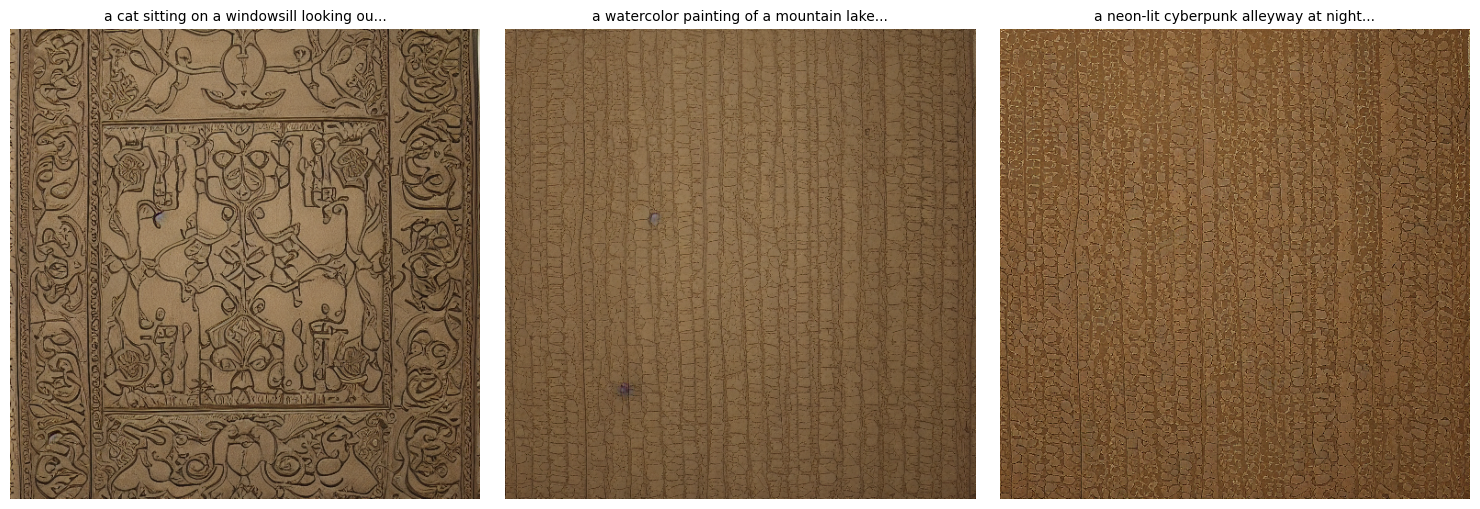

In [15]:
# @title 5.1 Generate Image + Prompt Sensitivity Diagnostics
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import DPMSolverMultistepScheduler
from tqdm import tqdm

vae.to(device).eval()
unet.to(device).eval()
gemma_model.eval()
clip_model.eval()

infer_scheduler = DPMSolverMultistepScheduler.from_pretrained(SD_ID, subfolder="scheduler")
vae_dtype = next(vae.parameters()).dtype

@torch.no_grad()
def make_dual_condition(prompts, include_clip=True, include_gemma=True):
    clip_h, clip_mask = encode_clip_prompts(prompts)
    gemma_h, gemma_mask = encode_gemma_prompts(prompts)
    if not include_clip:
        clip_h = torch.zeros_like(clip_h)
    if not include_gemma:
        gemma_h = torch.zeros_like(gemma_h)
    return clip_h, clip_mask, gemma_h, gemma_mask

@torch.no_grad()
def generate(prompt, steps=30, guidance=5.0, seed=42, clip_scale=0.0, gemma_scale=1.0):
    gen = torch.Generator(device=device).manual_seed(seed)
    infer_scheduler.set_timesteps(steps, device=device)

    cond_clip, cond_clip_mask, cond_gemma, cond_gemma_mask = make_dual_condition([prompt])
    uncond_clip, uncond_clip_mask, uncond_gemma, uncond_gemma_mask = make_dual_condition([""])
    clip_h = torch.cat([uncond_clip, cond_clip], dim=0)
    clip_mask = torch.cat([uncond_clip_mask, cond_clip_mask], dim=0)
    gemma_h = torch.cat([uncond_gemma, cond_gemma], dim=0)
    gemma_mask = torch.cat([uncond_gemma_mask, cond_gemma_mask], dim=0)

    latents = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    latents = latents * infer_scheduler.init_noise_sigma
    set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=clip_scale, gemma_scale=gemma_scale)

    for t in tqdm(infer_scheduler.timesteps, desc="Generating"):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        pred = unet(
            inp,
            t,
            encoder_hidden_states=clip_h,
            encoder_attention_mask=clip_mask,
        ).sample
        u, p = pred.chunk(2)
        pred = u + guidance * (p - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample

    latents = (latents / vae.config.scaling_factor).to(dtype=vae_dtype)
    img = vae.decode(latents).sample
    img = (img / 2 + 0.5).clamp(0, 1)
    img = img.cpu().permute(0, 2, 3, 1).float().numpy()
    return Image.fromarray((img[0] * 255).astype(np.uint8))

@torch.no_grad()
def prompt_sensitivity(prompts, seed=123, timestep=500, clip_scale=0.0, gemma_scale=1.0):
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device)
    preds = []
    for ptxt in prompts:
        clip_h, clip_mask, gemma_h, gemma_mask = make_dual_condition([ptxt])
        set_dual_attention_context(unet, gemma_encoder_hidden_states=gemma_h, gemma_attention_mask=gemma_mask, clip_scale=clip_scale, gemma_scale=gemma_scale)
        pred = unet(
            latent,
            t,
            encoder_hidden_states=clip_h,
            encoder_attention_mask=clip_mask,
        ).sample.float()
        preds.append(pred)
    base = preds[0].pow(2).mean().sqrt().item() + 1e-8
    for i in range(len(prompts)):
        for j in range(i + 1, len(prompts)):
            diff = (preds[i] - preds[j]).pow(2).mean().sqrt().item()
            print(f"{i} vs {j}: relative diff = {diff / base:.6f}")

prompts = [
    "a cat sitting on a windowsill looking outside",
    "a watercolor painting of a mountain lake",
    "a neon-lit cyberpunk alleyway at night",
]

print("Prompt sensitivity, Gemma-only:")
prompt_sensitivity(prompts, clip_scale=0.0, gemma_scale=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ptxt in zip(axes, prompts):
    print(f"Generating Gemma-only: {ptxt}")
    img = generate(ptxt, steps=30, guidance=5.0, clip_scale=0.0, gemma_scale=1.0)
    ax.imshow(img)
    ax.set_title(ptxt[:40] + "...", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/samples_gemma_only.png", dpi=100)
plt.show()


In [16]:
# @title 5.2 Save Dual + Pruned Gemma-Only Checkpoints
import os

# Merge LoRA wrappers first so both dual and pruned checkpoints strict-reload into plain Linear modules.
def merge_lora_linear(m):
    if not isinstance(m, ManualLoRA):
        return m
    base = m.base
    delta = (m.lora_B.weight @ m.lora_A.weight) * m.scaling
    base.weight.data.add_(delta.to(device=base.weight.device, dtype=base.weight.dtype))
    return base

def merge_all_lora(module):
    for child_name, child in list(module.named_children()):
        if isinstance(child, ManualLoRA):
            setattr(module, child_name, merge_lora_linear(child))
        else:
            merge_all_lora(child)

merge_all_lora(unet)
print("LoRA wrappers merged before checkpoint save; strict reload graphs use plain Linear modules.")

# Dual checkpoint: needs this notebook's DualNativeAttention class to reload.
dual_path = f"{DRIVE_OUT}/gemma3_sd_dual_native_checkpoint.pt"
torch.save({
    "unet_state_dict": {k: v.detach().cpu() for k, v in unet.state_dict().items()},
    "unet_config": dict(unet.config),
    "architecture": "DualNativeAttention(CLIP scaffold + native Gemma branch)",
    "gemma_model_id": gemma_path,
    "clip_model_id": CLIP_ID,
    "gemma_hidden_size": gemma_hidden_size,
    "clip_hidden_size": clip_hidden_size,
    "max_gemma_len": MAX_GEMMA_LEN,
    "uses_kv_bias": True,
    "merged_lora": True,
    "reload_note": "Rebuild SD1.5 UNet, apply_dual_native_attention(unet, gemma_hidden_size), then load_state_dict(strict=True).",
}, dual_path)
print(f"Dual merged checkpoint saved: {dual_path}")

# Pruned checkpoint: physically removes CLIP branch from live UNet while preserving Gemma LayerNorm.
pruned_count = prune_to_gemma_only(unet)
pruned_path = f"{DRIVE_OUT}/gemma3_sd_gemma_only_pruned.pt"
torch.save({
    "unet_state_dict": {k: v.detach().cpu() for k, v in unet.state_dict().items()},
    "unet_config": dict(unet.config),
    "architecture": "GemmaOnlyAttention wrapper; no CLIP branch in inference graph",
    "gemma_model_id": gemma_path,
    "gemma_hidden_size": gemma_hidden_size,
    "new_cross_attention_dim": gemma_hidden_size,
    "max_gemma_len": MAX_GEMMA_LEN,
    "uses_kv_bias": True,
    "merged_lora": True,
    "pruned_dual_modules": pruned_count,
    "reload_note": "Rebuild SD1.5 UNet, apply_dual_native_attention(unet, gemma_hidden_size), prune_to_gemma_only(unet), then load_state_dict(strict=True). No CLIP required for inference.",
}, pruned_path)
size_gb = os.path.getsize(pruned_path) / 1e9
print(f"Gemma-only pruned checkpoint saved: {pruned_path} ({size_gb:.2f} GB)")
print(f"Pruned modules: {pruned_count}")


LoRA wrappers merged before checkpoint save; strict reload graphs use plain Linear modules.
Dual merged checkpoint saved: /content/drive/MyDrive/gemma3-sd/gemma3_sd_dual_native_checkpoint.pt
Gemma-only pruned checkpoint saved: /content/drive/MyDrive/gemma3-sd/gemma3_sd_gemma_only_pruned.pt (3.43 GB)
Pruned modules: 16


In [17]:
# @title 5.3 Reload Checkpoint Smoke Test (optional)
# Proves saved artifacts can be reconstructed in a fresh runtime.

RUN_RELOAD_SMOKE_TEST = False  # Set True after 5.2 if you want immediate strict reload verification.

if RUN_RELOAD_SMOKE_TEST:
    from diffusers import UNet2DConditionModel

    # Dual reload: CLIP scaffold + Gemma branch.
    dual_path = f"{DRIVE_OUT}/gemma3_sd_dual_native_checkpoint.pt"
    dual_ckpt = torch.load(dual_path, map_location="cpu")
    dual_unet = UNet2DConditionModel.from_pretrained(
        SD_ID,
        subfolder="unet",
        torch_dtype=unet_dtype,
    ).to(device)
    n = apply_dual_native_attention(dual_unet, dual_ckpt["gemma_hidden_size"])
    print(f"Reload dual surgery applied: {n} modules")
    dual_unet.load_state_dict(dual_ckpt["unet_state_dict"], strict=True)
    dual_unet.eval()
    print("Dual checkpoint reload: PASS (strict=True)")

    # Pruned reload: no CLIP branch in attention graph.
    pruned_path = f"{DRIVE_OUT}/gemma3_sd_gemma_only_pruned.pt"
    pruned_ckpt = torch.load(pruned_path, map_location="cpu")
    pruned_unet = UNet2DConditionModel.from_pretrained(
        SD_ID,
        subfolder="unet",
        torch_dtype=unet_dtype,
    ).to(device)
    n = apply_dual_native_attention(pruned_unet, pruned_ckpt["gemma_hidden_size"])
    pcount = prune_to_gemma_only(pruned_unet)
    print(f"Reload pruned surgery applied: dual={n}, pruned={pcount}")
    pruned_unet.load_state_dict(pruned_ckpt["unet_state_dict"], strict=True)
    pruned_unet.eval()
    print("Pruned Gemma-only checkpoint reload: PASS (strict=True)")
else:
    print("Reload smoke test skipped. Set RUN_RELOAD_SMOKE_TEST=True after saving to verify strict reload.")


Reload smoke test skipped. Set RUN_RELOAD_SMOKE_TEST=True after saving to verify strict reload.


## Roadmap & Next Steps

Current branch implements the CLIP-scaffold → native Gemma branch route.

Milestones:

1. **Dual smoke test**: `clip_scale=1, gemma_scale=0` reproduces CLIP path; `clip_scale=0, gemma_scale=1` is finite.
2. **Warmup**: train only Gemma branch with CLIP teacher and CLIP dropout.
3. **Anneal**: move schedule from mostly CLIP to Gemma-only while monitoring prompt sensitivity.
4. **Prune**: save Gemma-only UNet checkpoint requiring no CLIP in inference graph.
5. **Longer prompts**: only after Gemma-only at 77 tokens works; then test 128/256 separately.

Permanent diagnostics:

- generated grids: CLIP-only / dual / Gemma-only
- prompt sensitivity relative prediction deltas
- loss_diffusion vs loss_teacher
- CFG sweep: 3.0, 5.0, 7.5
- strict reload smoke test before trusting checkpoints


## Appendix: download_hf_dataset.py

Run this cell to write the download script to disk, then execute it above.

In [18]:
# @title Appendix: Alternative Dataset (not used)
# This cell is a reference only. The training pipeline uses
# jackyhate/text-to-image-2M via streaming. No download needed.
# To switch datasets, change the load_dataset() call in cells 17/20.
